# TAC sample normalization — ultra-fast diagnostic

This notebook is only for answering:

1. Does the observable HOME sample change substantially over time?
2. Is that change spatially uneven across venue-relevant geohash6 origins?
3. Are the implied normalization weights reasonably behaved?

It deliberately avoids scanning for all available snapshot dates.

Instead, it queries a small set of exact dates:
- six monthly baseline dates in July–December 2023;
- one quarterly-ish date thereafter through June 2026.

If some exact dates do not exist in `DEVICE_RECURRING_AREA`, they will simply return no rows. If too many are missing, adjust the dates after checking one known month.

In [1]:
from contextlib import contextmanager
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 50)

@contextmanager
def timer(label: str):
    start = time.time()
    print(f"[START] {label}")
    try:
        yield
    finally:
        print(f"[DONE]  {label} ({time.time() - start:,.2f}s)")

In [2]:
%load_ext cuebiqmagic.magics
%init_cuebiq_data
snow_engine = get_ipython().user_ns["instance"]
print("Snowflake connection initialized.")


schema : args.schema='paas_cda_pe_v3' and database: args.database='cuebiq_data' used
The connection to the Snowflake cluster has been established using database 'cuebiq_data' and schema 'paas_cda_pe_v3'.

You can now retrieve the connection using the following statement:
snow_engine = get_ipython().user_ns['instance']

The connection offers two methods


snow_engine.execute_statement("<SQL Statement>") # execute the SQL statement.


snow_engine.read_sql("<SQL Statement>") # execute the SQL statement and return a Pandas DataFrame.


snow_engine.write_dataframe(dataframe:pd.DataFrame, table_name:str,schema:str, index_in=False, if_exists_in="append",method_in="multi")
Snowflake connection initialized.


In [3]:
# Copy/import the same Snowflake connection setup used in the TAC notebook.

RECURRING_AREA_TABLE = "DEVICE_RECURRING_AREA"

PROVIDER_ID = "PAPA"
COUNTRY_CODE = "CA"
HOME_TAG = "HOME"
HOME_CONFIDENCE_MIN = 0.60

VENUE_HOMES_MONTHLY_PATH = Path("./activity/venues_homes_monthly.csv")

# Small fixed set of test dates.
# These use the 15th of selected months purely as a lightweight diagnostic.
TEST_DATES = [
    # 2023H2 baseline
    20230715,
    20230815,
    20230915,
    20231015,
    20231115,
    20231215,

    # Sparse checks afterward
    20240315,
    20240615,
    20240915,
    20241215,
    20250315,
    20250615,
    20250915,
    20251215,
    20260315,
    20260615,
]

BASELINE_DATES = {
    20230715,
    20230815,
    20230915,
    20231015,
    20231115,
    20231215,
}

## 1. Restrict to HOME geohash6 origins that actually appear in venue activity

In [4]:
venue_homes = pd.read_csv(VENUE_HOMES_MONTHLY_PATH)

venue_homes["home_geohash6"] = (
    venue_homes["home_geohash6"]
    .astype("string")
    .str.strip()
    .str.lower()
)

venue_origins = (
    venue_homes.loc[
        venue_homes["time_period"].astype(str).str.lower().eq("all"),
        "home_geohash6",
    ]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print(f"Venue-relevant HOME geohash6 cells: {len(venue_origins):,}")

Venue-relevant HOME geohash6 cells: 1,182


## 2. Query only the selected exact dates

This is the only Snowflake-heavy cell.

In [5]:
date_sql = ", ".join(str(x) for x in TEST_DATES)
geohash_sql = ", ".join(f"'{g}'" for g in venue_origins)

sql_samples = f'''
SELECT
    SNAPSHOT_EVENT_DATE,
    LOWER(GEOHASH_ID) AS HOME_GEOHASH6,
    COUNT(DISTINCT CUEBIQ_ID) AS OBSERVABLE_DEVICES
FROM {RECURRING_AREA_TABLE}
WHERE PROVIDER_ID = '{PROVIDER_ID}'
  AND COUNTRY_CODE = '{COUNTRY_CODE}'
  AND TAG_TYPE_CODE = '{HOME_TAG}'
  AND CONFIDENCE_LEVEL >= {HOME_CONFIDENCE_MIN}
  AND SNAPSHOT_EVENT_DATE IN ({date_sql})
  AND LOWER(GEOHASH_ID) IN ({geohash_sql})
GROUP BY SNAPSHOT_EVENT_DATE, LOWER(GEOHASH_ID)
ORDER BY SNAPSHOT_EVENT_DATE, HOME_GEOHASH6
'''

with timer("Count observable HOME devices on selected dates"):
    samples = snow_engine.read_sql(sql_samples)

print(f"Rows returned: {len(samples):,}")
print(f"Dates returned: {samples['snapshot_event_date'].nunique():,}")
print(f"Geohash6 cells returned: {samples['home_geohash6'].nunique():,}")

print("\nRequested dates:")
print(TEST_DATES)

print("\nDates actually returned:")
print(sorted(samples["snapshot_event_date"].unique().tolist()))

display(samples.head())

[START] Count observable HOME devices on selected dates
[DONE]  Count observable HOME devices on selected dates (53.85s)
Rows returned: 18,894
Dates returned: 16
Geohash6 cells returned: 1,182

Requested dates:
[20230715, 20230815, 20230915, 20231015, 20231115, 20231215, 20240315, 20240615, 20240915, 20241215, 20250315, 20250615, 20250915, 20251215, 20260315, 20260615]

Dates actually returned:
[20230715, 20230815, 20230915, 20231015, 20231115, 20231215, 20240315, 20240615, 20240915, 20241215, 20250315, 20250615, 20250915, 20251215, 20260315, 20260615]


,snapshot_event_date,home_geohash6,observable_devices
0,20230715,dpxrvy,94
1,20230715,dpxrvz,412
2,20230715,dpxryp,383
3,20230715,dpxryr,186
4,20230715,dpz2gc,235


## 3. Check missing test dates

If most dates are missing, stop here and replace `TEST_DATES` with dates you know exist.

If most or all are present, continue.

In [6]:
returned_dates = set(samples["snapshot_event_date"].astype(int).unique())
missing_dates = [d for d in TEST_DATES if d not in returned_dates]

print(f"Missing requested dates: {len(missing_dates)}")
print(missing_dates)

Missing requested dates: 0
[]


## 4. Build a simple 2023H2 baseline

In [7]:
baseline = (
    samples.loc[samples["snapshot_event_date"].isin(BASELINE_DATES)]
    .groupby("home_geohash6", as_index=False)
    .agg(
        baseline_mean=("observable_devices", "mean"),
        baseline_sd=("observable_devices", "std"),
        baseline_min=("observable_devices", "min"),
        baseline_max=("observable_devices", "max"),
        baseline_n=("observable_devices", "size"),
    )
)

baseline["baseline_cv"] = baseline["baseline_sd"] / baseline["baseline_mean"]

display(
    baseline["baseline_mean"]
    .describe(percentiles=[.05, .10, .25, .5, .75, .9, .95])
    .to_frame("baseline_mean_devices")
)

display(
    baseline["baseline_cv"]
    .describe(percentiles=[.10, .25, .5, .75, .9, .95])
    .to_frame("baseline_cv")
)

,baseline_mean_devices
count,1182.000000
mean,552.064354
std,580.230427
min,1.600000
5%,34.191667
10%,68.366667
25%,206.750000
50%,409.166667
75%,712.625000
90%,1107.483333


,baseline_cv
count,1182.000000
mean,0.292195
std,0.165263
min,0.109980
10%,0.174934
25%,0.199923
50%,0.237928
75%,0.314028
90%,0.475784
95%,0.617667


## 5. Calculate candidate normalization ratios

`sample_ratio = baseline_mean / current_sample`

In [8]:
sample_index = samples.merge(
    baseline[
        ["home_geohash6", "baseline_mean", "baseline_cv", "baseline_n"]
    ],
    on="home_geohash6",
    how="left",
)

sample_index["sample_ratio"] = (
    sample_index["baseline_mean"]
    / sample_index["observable_devices"]
)

display(
    sample_index["sample_ratio"]
    .describe(percentiles=[.01, .05, .10, .25, .5, .75, .9, .95, .99])
)

for factor in [1.5, 2.0, 3.0]:
    share = (
        (sample_index["sample_ratio"] < 1 / factor)
        | (sample_index["sample_ratio"] > factor)
    ).mean()

    print(f"Outside ±{factor:.1f}×: {share:.2%}")

count    18894.000000
mean         0.807053
std          0.388649
min          0.000149
1%           0.197648
5%           0.362549
10%          0.451990
25%          0.592849
50%          0.735423
75%          0.978445
90%          1.202020
95%          1.345614
99%          1.986676
max         10.214286
Name: sample_ratio, dtype: float64

Outside ±1.5×: 39.35%
Outside ±2.0×: 15.26%
Outside ±3.0×: 4.19%


## 6. Check whether sparse origins actually matter for venue activity

In [9]:
origin_volume = (
    venue_homes.loc[
        venue_homes["time_period"].astype(str).str.lower().eq("all")
    ]
    .groupby("home_geohash6", as_index=False)
    .agg(venue_visits=("visit_count", "sum"))
)

diag = baseline.merge(
    origin_volume,
    on="home_geohash6",
    how="left",
)

diag["venue_visits"] = diag["venue_visits"].fillna(0)

total_visits = diag["venue_visits"].sum()

for threshold in [10, 20, 30, 50]:
    affected = diag.loc[
        diag["baseline_mean"] < threshold,
        "venue_visits",
    ].sum()

    print(
        f"Venue visits from origins with baseline < {threshold}: "
        f"{affected:,.0f} "
        f"({affected / total_visits:.1%})"
    )

Venue visits from origins with baseline < 10: 84 (0.1%)
Venue visits from origins with baseline < 20: 104 (0.1%)
Venue visits from origins with baseline < 30: 179 (0.1%)
Venue visits from origins with baseline < 50: 348 (0.2%)


## 7. Very simple time trend

This is only a diagnostic of whether sample ratios shift over time.

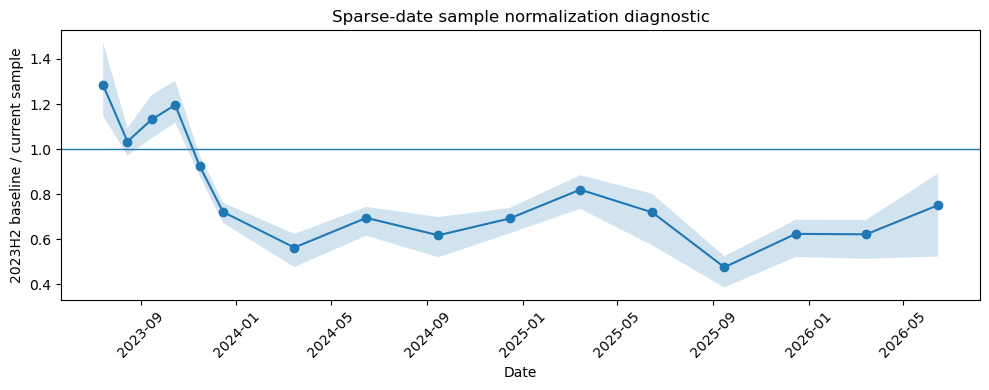

,snapshot_event_date,median_ratio,p25_ratio,p75_ratio,date
0,20230715,1.282992,1.146744,1.472652,2023-07-15
1,20230815,1.033514,0.971299,1.092605,2023-08-15
2,20230915,1.131281,1.047872,1.240182,2023-09-15
3,20231015,1.195704,1.116874,1.302767,2023-10-15
4,20231115,0.925926,0.883044,0.975926,2023-11-15
5,20231215,0.721049,0.671929,0.762255,2023-12-15
6,20240315,0.562837,0.476389,0.623744,2024-03-15
7,20240615,0.694444,0.615369,0.743425,2024-06-15
8,20240915,0.617307,0.519338,0.698246,2024-09-15
9,20241215,0.691934,0.626463,0.738688,2024-12-15


In [10]:
date_summary = (
    sample_index.groupby("snapshot_event_date")
    .agg(
        median_ratio=("sample_ratio", "median"),
        p25_ratio=("sample_ratio", lambda s: s.quantile(.25)),
        p75_ratio=("sample_ratio", lambda s: s.quantile(.75)),
    )
    .reset_index()
)

date_summary["date"] = pd.to_datetime(
    date_summary["snapshot_event_date"].astype(str),
    format="%Y%m%d",
)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    date_summary["date"],
    date_summary["median_ratio"],
    marker="o",
)

ax.fill_between(
    date_summary["date"],
    date_summary["p25_ratio"],
    date_summary["p75_ratio"],
    alpha=0.2,
)

ax.axhline(1.0, linewidth=1)
ax.set_title("Sparse-date sample normalization diagnostic")
ax.set_ylabel("2023H2 baseline / current sample")
ax.set_xlabel("Date")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(date_summary)

## Interpretation

This ultra-fast version is enough to decide whether the idea is promising.

If:
- baseline samples are usually reasonably large,
- baseline CVs are modest,
- sample ratios move systematically over time,
- and extreme ratios are uncommon,

then geohash6-level normalization is likely viable.

If exact test dates are mostly absent, the next step is not a three-year date scan. Instead, query one short month to determine the actual recurring-area snapshot pattern, then substitute known valid dates into `TEST_DATES`.